# EDA: test.csv

This notebook performs exploratory data analysis on `data/hackathon-recover-x-cogito/test.csv`.
Sections:
- Import libraries
- Load and inspect data
- Missing values
- Data types and conversions
- Univariate analysis
- Bivariate analysis (correlations, merges with metaData)
- Multivariate analysis
- Save processed data

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from IPython.display import display

## Load and Inspect Data
Load `test.csv` and show a quick summary (head, shape, dtypes).

In [4]:
file_path = "../data/hackathon-recover-x-cogito/test.csv"
test = pd.read_csv(file_path)
print('Shape:', test.shape)
test.head()

Shape: (167173, 5)


,id,project_id,room,work_operation_cluster_name,work_operation_cluster_code
0,0,147529,Bod,Grovrengjøring og desinfisering av overflater,104
1,0,147529,Bod,Intern flytting av innbo mellom rom,204
2,0,147529,Bod,Byggvask,108
3,1,147529,Gang,Riv gulvlist,49
4,1,147529,Gang,Riv veggpanel,345


## Missing Values
Identify and visualize missingness.

In [5]:
mv = test.isnull().sum().sort_values(ascending=False)
mv_percent = (test.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([mv, mv_percent], axis=1)
missing_df.columns = ['missing_count','missing_percent']
missing_df[missing_df['missing_count']>0].head(30)

# plot top missing
top_miss = missing_df[missing_df['missing_count']>0].head(20)
if not top_miss.empty:
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_miss['missing_percent'], y=top_miss.index, palette='viridis')
    plt.xlabel('Percent missing')
    plt.title('Top missing columns in test.csv')
    plt.show()
else:
    print('No missing values in test.csv')

No missing values in test.csv


## Data types & conversions
Try conversions and summarize types.

In [6]:
# Convert date-like columns
for c in test.columns:
    if 'date' in c.lower() or 'time' in c.lower():
        test[c] = pd.to_datetime(test[c], errors='coerce')

# Convert numeric-like object columns
for c in test.select_dtypes(include=['object']).columns:
    conv = pd.to_numeric(test[c].str.replace(',',''), errors='coerce')
    if conv.notnull().sum() >= len(test)*0.8:
        test[c] = conv
        print(f'Converted {c} to numeric')

# Show types after
test.dtypes.value_counts()

int64     3
object    2
Name: count, dtype: int64

## Univariate analysis
- Numeric: describe, histograms
- Categorical: top frequencies

Numeric: 3, Categorical: 2


,count,mean,std,min,25%,50%,75%,max
id,167173.0,9042.570092,5280.758073,0.0,4636.0,8659.0,13798.0,18298.0
project_id,167173.0,213853.896102,38406.418229,147487.0,180909.0,214020.0,247810.0,280521.0
work_operation_cluster_code,167173.0,137.019937,103.900116,0.0,53.0,121.0,204.0,387.0


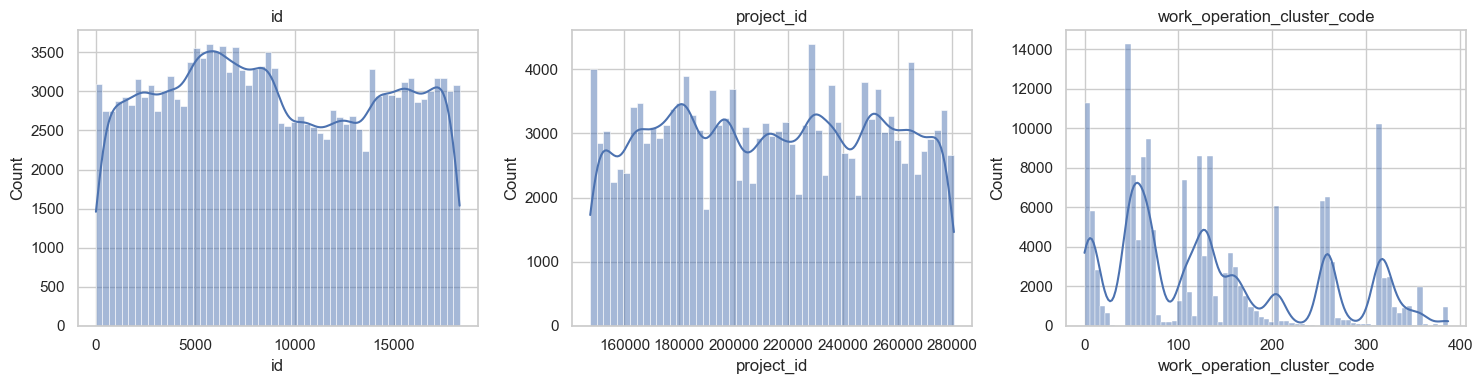


Top for room (unique 2232):


room
Kjøkken          23781
Stue             18937
Gang             16831
Soverom          16596
Bad               9599
Bod               7647
Andre områder     7245
Vaskerom          4902
Gang 2            3679
Wc                3458
Soverom 2         3396
Stue/kjøkken      3094
Kjeller           2201
Bod 2             1700
Utvendig          1690
Kjøkken/stue      1191
Kjellerstue       1190
Stue 2            1126
Soverom 3          998
Kjøkken 2          987
Name: count, dtype: int64

C:\Users\tobia\AppData\Local\Temp\ipykernel_13416\3066122221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='crest')


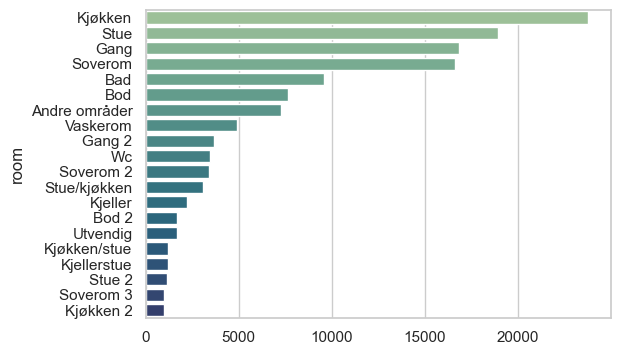


Top for work_operation_cluster_name (unique 361):


work_operation_cluster_name
Lett beskyttelse av gulv med dekkepapp    6279
Intern flytting av innbo mellom rom       5834
Byggvask                                  5439
Ny gulvlist                               5157
Riv gulvlist                              5135
Ny gulv                                   4726
Ny spikerslag/kubbing                     3836
Kapping, tverrsaging av plater/panel      3731
Riv flytende gulv                         3722
Ny innv karmlist                          3666
Ny underlag for parkett/laminat           3643
Riv innv karmlist                         3639
Riv underlagsmateriale                    3573
Riv taklist                               2982
Ny taklister                              2954
Ny dampsperre                             2943
Ny feielist                               2895
Riv feielist                              2840
Riv dampsperre / vindsperre               2772
Ny isolasjon i vegg                       2435
Name: count, dtype: int64

C:\Users\tobia\AppData\Local\Temp\ipykernel_13416\3066122221.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette='crest')


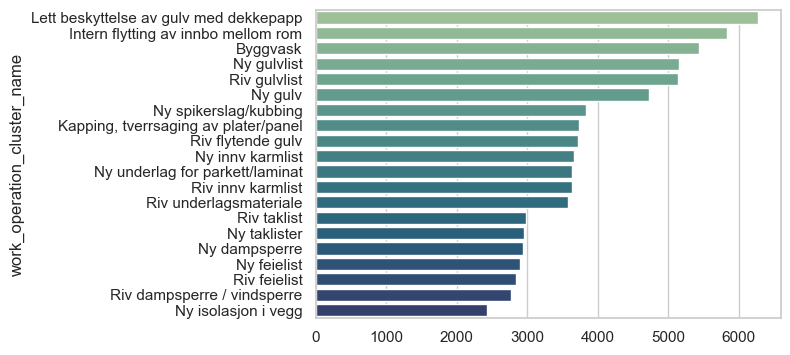

In [7]:
# Numeric and categorical columns
num_cols = test.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = test.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")

if num_cols:
    display(test[num_cols].describe().T)
    # Histograms
    plot_cols = num_cols[:12]
    n = len(plot_cols)
    ncols = 3
    nrows = (n + ncols - 1)//ncols
    plt.figure(figsize=(5*ncols, 4*nrows))
    for i,c in enumerate(plot_cols,1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(test[c].dropna(), kde=True)
        plt.title(c)
    plt.tight_layout()
    plt.show()

if cat_cols:
    for c in cat_cols[:10]:
        vc = test[c].value_counts(dropna=False).head(20)
        print(f"\nTop for {c} (unique {test[c].nunique(dropna=False)}):")
        display(vc)
        plt.figure(figsize=(6, min(4, len(vc)*0.25+1)))
        sns.barplot(x=vc.values, y=vc.index, palette='crest')
        plt.show()

## Bivariate Analysis
Correlations between numeric columns, and relationships with project metadata from metaData.csv.

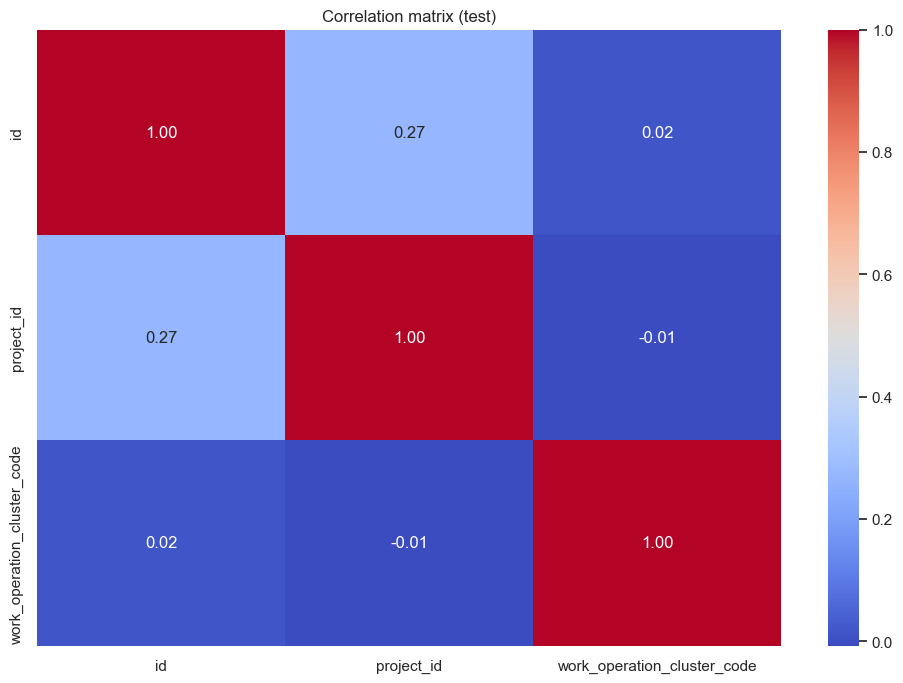

Merged shape: (5994, 9)


,project_id,total_ops,distinct_ops,insurance_company,recover_office_zip_code,damage_address_zip_code,office_distance,case_creation_year,case_creation_month
0,147487,22,19,J,5430.0,5430.0,"3,1",2020,1
1,147528,97,55,K,977.0,1462.0,6,2023,4
2,147529,63,38,K,6783.0,6091.0,"96,2",2024,1
3,147549,8,8,C,4580.0,4521.0,"27,1",2023,4
4,147556,21,10,E,283.0,1363.0,"7,3",2022,5


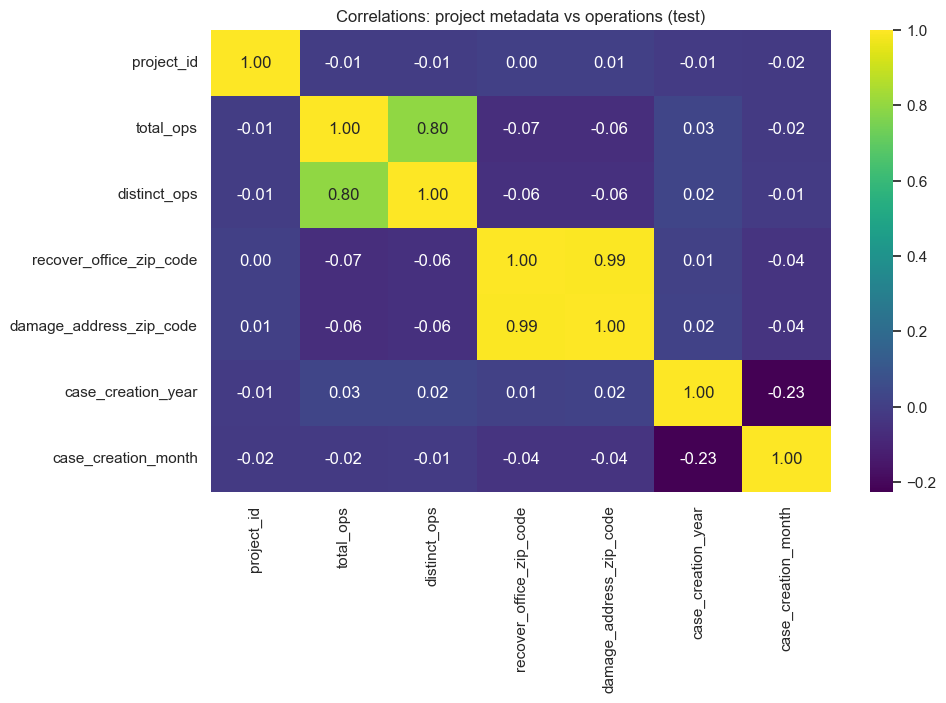

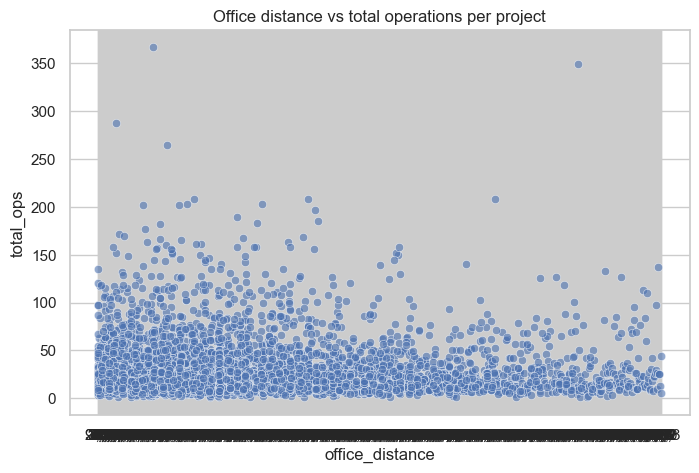

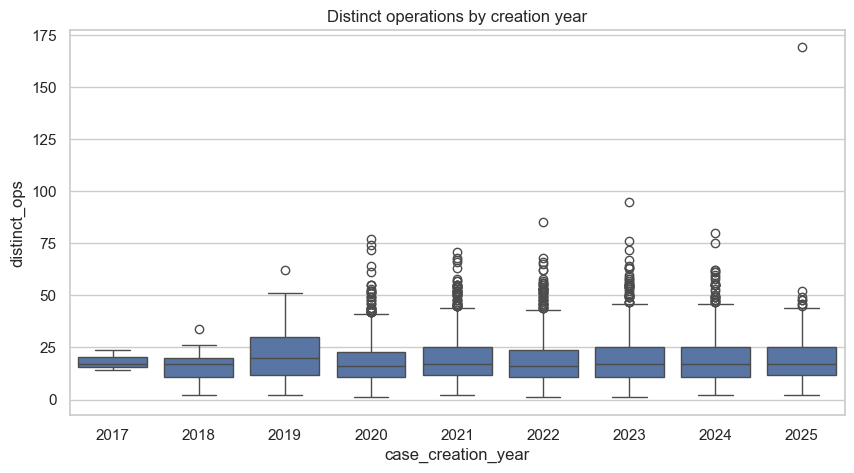

In [8]:
# Correlation heatmap for numeric columns
if num_cols:
    plt.figure(figsize=(12,8))
    sns.heatmap(test[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation matrix (test)')
    plt.show()

# Merge with metaData to analyze relationships
import os
meta_path = '../data/hackathon-recover-x-cogito/metaData.csv'
if os.path.exists(meta_path):
    meta = pd.read_csv(meta_path)
    # Aggregate operations per project
    ops_per_proj = test.groupby('project_id').size().reset_index(name='total_ops')
    distinct_ops = test.groupby('project_id')['work_operation_cluster_code'].nunique().reset_index(name='distinct_ops')
    proj_agg = ops_per_proj.merge(distinct_ops, on='project_id')
    # Merge with meta
    merged = proj_agg.merge(meta, on='project_id', how='left')
    print('Merged shape:', merged.shape)
    display(merged.head())

    # Correlations between project features and operations
    num_meta_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
    if num_meta_cols:
        plt.figure(figsize=(10,6))
        sns.heatmap(merged[num_meta_cols].corr(), annot=True, cmap='viridis', fmt='.2f')
        plt.title('Correlations: project metadata vs operations (test)')
        plt.show()

        # Scatter: office_distance vs total_ops
        plt.figure(figsize=(8,5))
        sns.scatterplot(data=merged, x='office_distance', y='total_ops', alpha=0.6)
        plt.title('Office distance vs total operations per project')
        plt.show()

        # Boxplot: case_creation_year vs distinct_ops
        plt.figure(figsize=(10,5))
        sns.boxplot(data=merged, x='case_creation_year', y='distinct_ops')
        plt.title('Distinct operations by creation year')
        plt.show()
else:
    print('metaData.csv not found')

## Multivariate Analysis
Pairplot for key numeric columns, and analysis of operation clusters by project features.

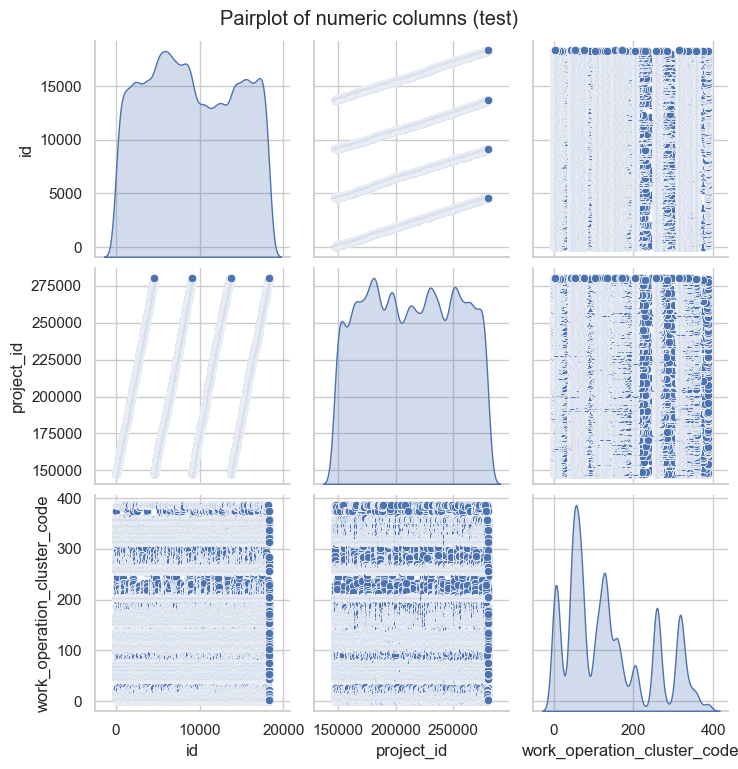

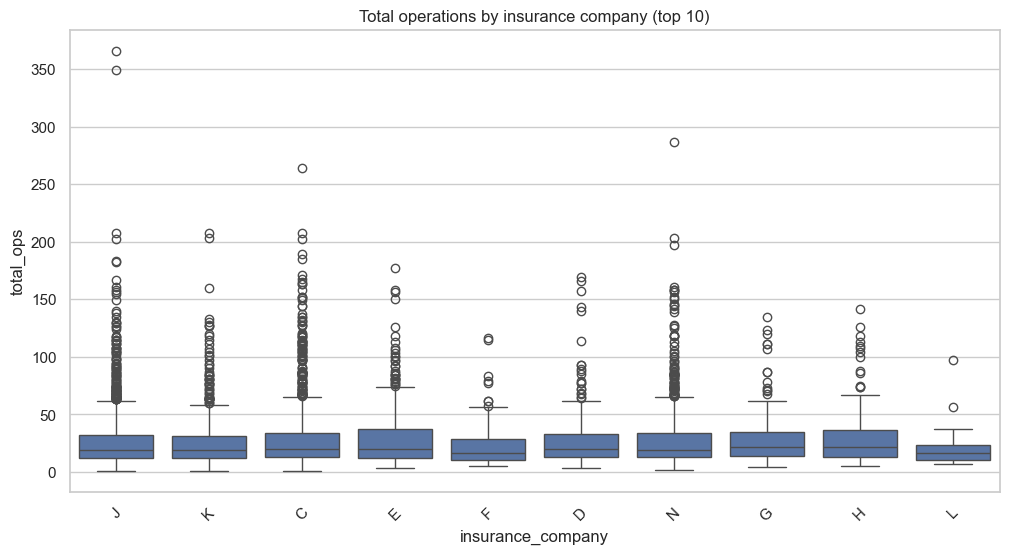

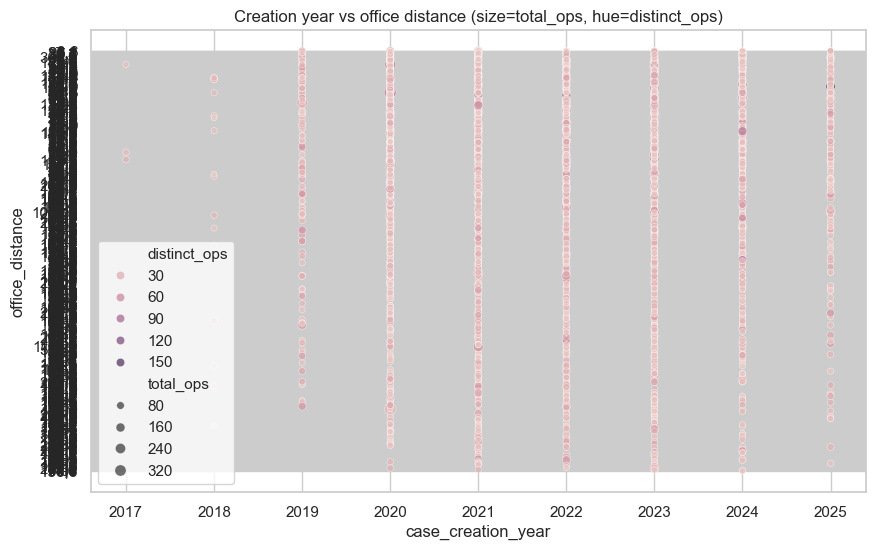

In [9]:
# Pairplot for numeric columns (sample if large)
if num_cols and len(num_cols) > 2:
    sample_cols = num_cols[:5]  # limit to 5 for readability
    sns.pairplot(test[sample_cols].dropna(), diag_kind='kde')
    plt.suptitle('Pairplot of numeric columns (test)', y=1.02)
    plt.show()

# If merged data exists, analyze operation clusters by insurance company
if 'merged' in locals() and not merged.empty:
    # Top insurance companies by project count
    top_ins = merged['insurance_company'].value_counts().head(10).index
    subset = merged[merged['insurance_company'].isin(top_ins)]
    plt.figure(figsize=(12,6))
    sns.boxplot(data=subset, x='insurance_company', y='total_ops')
    plt.title('Total operations by insurance company (top 10)')
    plt.xticks(rotation=45)
    plt.show()

    # Scatter: creation year vs distance, colored by total_ops
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=merged, x='case_creation_year', y='office_distance', size='total_ops', hue='distinct_ops', alpha=0.7)
    plt.title('Creation year vs office distance (size=total_ops, hue=distinct_ops)')
    plt.show()

## Save Processed Data
Save cleaned test data for further analysis.

In [10]:
# Save processed test data
test.to_csv('../data/hackathon-recover-x-cogito/test_processed.csv', index=False)
print('Saved test_processed.csv')

Saved test_processed.csv
